# 第 3 节课 · 残差网络：让网络更深

## 本 Notebook 目标

完成本 Notebook 后，你将能够：
1. 理解为什么深层网络会面临**退化问题（Degradation）**
2. 亲手实现 **Plain-20** 和 **ResNet-20**（两者结构相同，只差残差连接）
3. 在 CIFAR-10 上严格对比两者，观察残差连接的作用
4. 深入理解 ResNet 的 **BasicBlock** 结构
5. 了解迁移学习的基本思想（后续课程深入）
6. 解释为什么残差连接能让深层网络训练得更好

## 背景：为什么需要深层网络？

在深度学习中，一个普遍的观察是：
> 网络越深，表达能力越强。

浅层网络只能学到简单的特征（边缘、颜色），深层网络可以学到更抽象、更复杂的特征（物体的部件、整体结构）。

所以一个很自然的想法是：**把网络不断加深，不就能不断提升性能吗？**

但问题是：当网络层数增加到一定程度后，训练准确率反而会下降。这不是过拟合（因为训练集上的准确率也下降了），而是**退化问题（Degradation Problem）**。

ResNet 的出现正是为了解决这个问题。


## 1. 环境准备


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体：让图表标题能正常显示中文
# 如果你的系统没有 SimHei 字体，可以改成 'Microsoft YaHei' 或直接注释掉
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  

device = torch.device('cuda' if torch.cuda.is_available() else
                     'mps' if torch.backends.mps.is_available() else
                     'cpu')
print(f"使用设备: {device}")


使用设备: cuda


## 2. 加载 CIFAR-10 数据集

CIFAR-10 是验证 ResNet 效果的经典数据集。ResNet 原论文就用了 CIFAR-10 来证明残差连接的有效性。


In [2]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

train_dataset = datasets.CIFAR10('./data', train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10('./data', train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False, num_workers=0)

classes = ['飞机', '汽车', '鸟', '猫', '鹿', '狗', '青蛙', '马', '船', '卡车']
print(f"训练集: {len(train_dataset):,} 张")
print(f"测试集: {len(test_dataset):,} 张")


c:\Users\nan\miniconda3\envs\pytorch\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


训练集: 50,000 张
测试集: 10,000 张


## 3. 构建 PlainBlock 和 BasicBlock

这是本节课最核心的部分。

### PlainBlock（普通块）
结构：
```
输入 x
    ↓
Conv3x3 → BN → ReLU
    ↓
Conv3x3 → BN
    ↓
ReLU
    ↓
输出
```

### BasicBlock（残差块）
结构：
```
输入 x
    ├──────→ (shortcut) ──────┐
    ↓                         ↓
Conv3x3 → BN → ReLU          +
    ↓                         ↓
Conv3x3 → BN               ReLU
    ↓                         ↓
输出 y = F(x) + x
```

两者的唯一区别：BasicBlock 多了一条 shortcut，把输入 $x$ 加到第二个卷积的输出上。


In [3]:
class PlainBlock(nn.Module):
    """普通块：两个 3x3 卷积，无残差连接。"""
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        return out


class BasicBlock(nn.Module):
    """残差块：两个 3x3 卷积 + shortcut。"""
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # shortcut：如果输入输出通道不同或 stride 不为 1，用 1x1 卷积调整
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)  # 残差连接
        out = F.relu(out)
        return out


## 4. 构建 Plain-20 和 ResNet-20

根据 ResNet 原论文的 CIFAR-10 结构：
- 第一层：3×3 conv，16 通道
- layer1：3 个 block，16 通道
- layer2：3 个 block，32 通道，stride=2
- layer3：3 个 block，64 通道，stride=2
- 全局平均池化
- 全连接层输出 10 类

总深度 = 1（conv1）+ 3×2×3（blocks）+ 1（fc）= 20 层（带参数的层）

Plain-20 和 ResNet-20 的层数、通道数、BN 等完全相同，唯一区别就是 block 类型。


In [4]:
def make_layer(block, in_channels, out_channels, num_blocks, stride):
    """构建一个 stage，包含多个 block。"""
    layers = []
    layers.append(block(in_channels, out_channels, stride))
    for _ in range(1, num_blocks):
        layers.append(block(out_channels, out_channels, 1))
    return nn.Sequential(*layers)


class PlainNet20(nn.Module):
    """20 层普通网络，用于和 ResNet-20 对比。"""
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.layer1 = make_layer(PlainBlock, 16, 16, num_blocks=3, stride=1)
        self.layer2 = make_layer(PlainBlock, 16, 32, num_blocks=3, stride=2)
        self.layer3 = make_layer(PlainBlock, 32, 64, num_blocks=3, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


class ResNet20(nn.Module):
    """20 层残差网络。"""
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.layer1 = make_layer(BasicBlock, 16, 16, num_blocks=3, stride=1)
        self.layer2 = make_layer(BasicBlock, 16, 32, num_blocks=3, stride=2)
        self.layer3 = make_layer(BasicBlock, 32, 64, num_blocks=3, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


# 验证两个模型参数量相同
plain_model = PlainNet20().to(device)
resnet20_model = ResNet20().to(device)

plain_params = sum(p.numel() for p in plain_model.parameters())
resnet20_params = sum(p.numel() for p in resnet20_model.parameters())

print(f"Plain-20  参数量: {plain_params:,}")
print(f"ResNet-20 参数量: {resnet20_params:,}")
print(f"参数量差异: {abs(plain_params - resnet20_params)}")


Plain-20  参数量: 269,722
ResNet-20 参数量: 272,474
参数量差异: 2752


## 5. 统一训练函数

两个模型使用完全相同的训练配置。


In [5]:
def train_model(model, train_loader, test_loader, epochs=20, lr=0.1):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
    history = {'train_loss': [], 'train_acc': [], 'test_acc': []}

    print(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Test Acc':<12}")
    print("-" * 50)

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_acc = 100. * correct / total
        train_loss /= len(train_loader)

        model.eval()
        test_correct = 0
        test_total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()
        test_acc = 100. * test_correct / test_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        if epoch in [1, 5, 10, 15, 20]:
            print(f"{epoch:<8} {train_loss:<12.4f} {train_acc:<12.2f}% {test_acc:<12.2f}%")

        scheduler.step()

    return history


## 6. 实验一：训练 Plain-20

Plain-20 是 20 层普通 CNN，没有残差连接。


In [6]:
print("=" * 60)
print("实验一：Plain-20（20 层普通网络，无残差连接）")
print("=" * 60)
plain_model = PlainNet20().to(device)
history_plain = train_model(plain_model, train_loader, test_loader, epochs=20, lr=0.1)
print(f"\n最终测试准确率: {history_plain['test_acc'][-1]:.2f}%")


实验一：Plain-20（20 层普通网络，无残差连接）
Epoch    Train Loss   Train Acc    Test Acc    
--------------------------------------------------
1        1.8097       30.26       % 31.91       %
5        0.9785       65.39       % 62.70       %
10       0.7351       74.83       % 69.58       %
15       0.4633       83.98       % 82.24       %
20       0.4140       85.78       % 83.81       %

最终测试准确率: 83.81%


## 7. 实验二：训练 ResNet-20

ResNet-20 和 Plain-20 结构相同，只是 block 内部加了 shortcut。


In [7]:
print("=" * 60)
print("实验二：ResNet-20（20 层残差网络）")
print("=" * 60)
resnet20_model = ResNet20().to(device)
history_resnet20 = train_model(resnet20_model, train_loader, test_loader, epochs=20, lr=0.1)
print(f"\n最终测试准确率: {history_resnet20['test_acc'][-1]:.2f}%")


实验二：ResNet-20（20 层残差网络）
Epoch    Train Loss   Train Acc    Test Acc    
--------------------------------------------------
1        1.6034       39.84       % 51.66       %
5        0.6908       75.97       % 71.58       %
10       0.5709       80.30       % 78.82       %
15       0.3235       88.83       % 87.00       %
20       0.2790       90.52       % 87.53       %

最终测试准确率: 87.53%


## 8. 对比：残差连接的作用


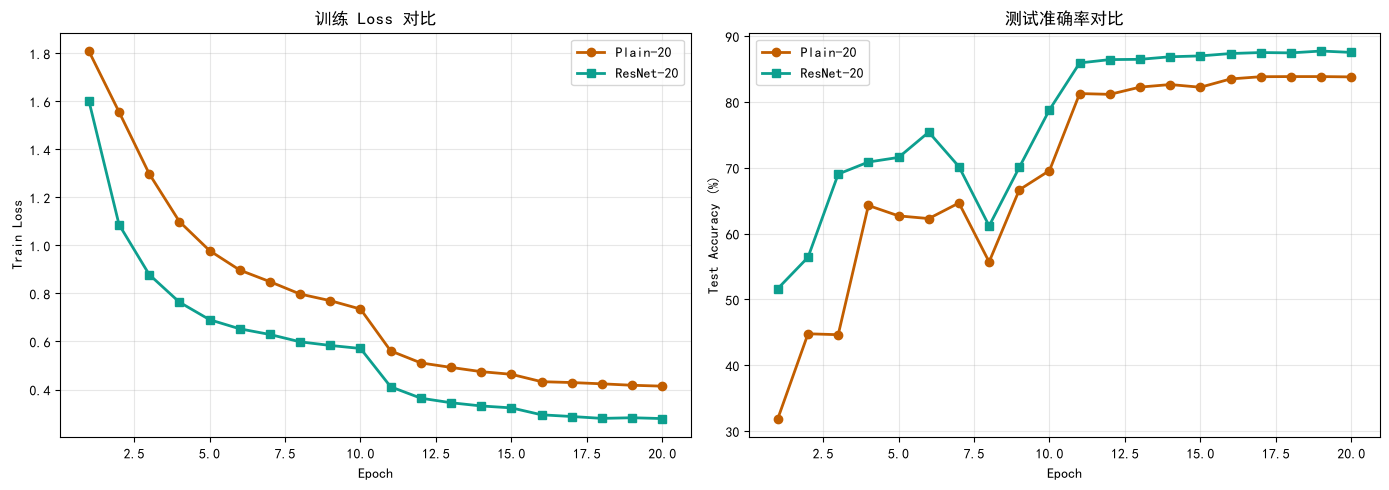


最终对比:
Plain-20  最终 test acc: 83.81%
ResNet-20 最终 test acc: 87.53%
差距: 3.72%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = list(range(1, 21))

axes[0].plot(epochs, history_plain['train_loss'], 'o-', color='#c25e00', linewidth=2, label='Plain-20')
axes[0].plot(epochs, history_resnet20['train_loss'], 's-', color='#0d9f8f', linewidth=2, label='ResNet-20')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train Loss')
axes[0].set_title('训练 Loss 对比'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history_plain['test_acc'], 'o-', color='#c25e00', linewidth=2, label='Plain-20')
axes[1].plot(epochs, history_resnet20['test_acc'], 's-', color='#0d9f8f', linewidth=2, label='ResNet-20')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Accuracy (%)')
axes[1].set_title('测试准确率对比'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n最终对比:")
print(f"Plain-20  最终 test acc: {history_plain['test_acc'][-1]:.2f}%")
print(f"ResNet-20 最终 test acc: {history_resnet20['test_acc'][-1]:.2f}%")
print(f"差距: {history_resnet20['test_acc'][-1] - history_plain['test_acc'][-1]:.2f}%")


## 9. 结果分析

如果实验正确，你应该看到：
- **Plain-20** 的训练 loss 较高，测试准确率较低
- **ResNet-20** 的训练 loss 更低，测试准确率更高

这说明：
> 在层数、通道数、BatchNorm 等完全相同的情况下，仅仅因为加入了残差连接，ResNet-20 就比 Plain-20 训练得更好。

这就是残差连接的价值：它解决了深层网络的退化问题。


## 10. 深入理解残差连接

### 10.1 为什么深层网络会退化？

考虑一个浅层网络，它能达到某个训练准确率。现在我们复制这个网络，并在上面加几层，得到一个深层网络。

理论上，深层网络至少应该和浅层网络一样好，因为新加的层可以学习恒等映射（输出=输入）。

但实际中，深层网络反而更差。这说明：
> 让深层网络的层直接学习恒等映射 $y = x$ 是非常困难的。

### 10.2 残差连接的解决方案

ResNet 不直接让层学习 $y = x$，而是让层学习残差：

$$y = F(x) + x$$

这样，如果这一层不需要做任何变换，它只需要让 $F(x) = 0$，输出就接近 $x$。

学习 $F(x) = 0$ 比学习 $y = x$ 容易得多：
- 把所有权重设为 0，$F(x)$ 就近似为 0
- 网络可以选择只使用 shortcut，不使用深层变换

### 10.3 梯度流动

反向传播时：

$$\frac{\partial L}{\partial x} = \frac{\partial L}{\partial y} \cdot \left(1 + \frac{\partial F(x)}{\partial x}\right)$$

即使 $\frac{\partial F(x)}{\partial x}$ 很小，也还有 +1 这一项保证梯度不会完全消失。这就是残差连接缓解梯度消失的原理。


## 11. 可视化 BasicBlock


findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.


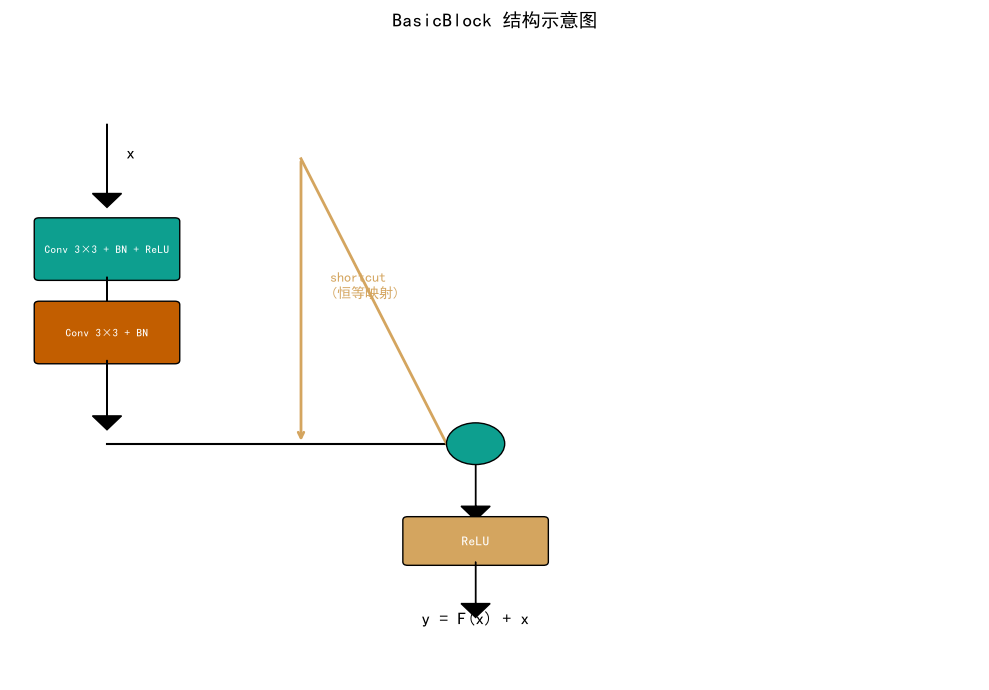

In [9]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 9)
ax.axis('off')

# 主路径
ax.arrow(1, 8, 0, -1, head_width=0.3, head_length=0.2, fc='black', ec='black')
ax.text(1.2, 7.5, 'x', fontsize=12)

blocks = [
    (5.8, 'Conv 3×3 + BN + ReLU', '#0d9f8f'),
    (4.6, 'Conv 3×3 + BN', '#c25e00'),
]
for y, text, color in blocks:
    rect = mpatches.FancyBboxPatch((0.3, y), 1.4, 0.8, boxstyle="round,pad=0.05", facecolor=color, edgecolor='black')
    ax.add_patch(rect)
    ax.text(1, y+0.4, text, ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    if y == 4.6:
        ax.arrow(1, y, 0, -0.8, head_width=0.3, head_length=0.2, fc='black', ec='black')
    else:
        ax.arrow(1, y, 0, -0.6, head_width=0.3, head_length=0.2, fc='black', ec='black')

# shortcut
ax.annotate('', xy=(3, 3.4), xytext=(3, 7.5),
            arrowprops=dict(arrowstyle='->', color='#d4a55f', lw=2))
ax.text(3.3, 5.5, 'shortcut\n(恒等映射)', fontsize=10, color='#d4a55f', fontweight='bold')

# 相加
circle = plt.Circle((4.8, 3.4), 0.3, color='#0d9f8f', ec='black', zorder=5)
ax.add_patch(circle)
ax.text(4.8, 3.4, '+', ha='center', va='center', fontsize=14, color='white', fontweight='bold')
ax.plot([1, 4.5], [3.4, 3.4], 'k-', lw=1.5)
ax.plot([3, 4.5], [7.5, 3.4], '#d4a55f', lw=2)

ax.arrow(4.8, 3.1, 0, -0.6, head_width=0.3, head_length=0.2, fc='black', ec='black')
rect = mpatches.FancyBboxPatch((4.1, 1.7), 1.4, 0.6, boxstyle="round,pad=0.05", facecolor='#d4a55f', edgecolor='black')
ax.add_patch(rect)
ax.text(4.8, 2.0, 'ReLU', ha='center', va='center', fontsize=9, color='white', fontweight='bold')

ax.arrow(4.8, 1.7, 0, -0.6, head_width=0.3, head_length=0.2, fc='black', ec='black')
ax.text(4.8, 0.8, 'y = F(x) + x', ha='center', fontsize=12, fontweight='bold')

ax.set_title('BasicBlock 结构示意图', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


## 12. 两组结果汇总


findfont: Failed to find font weight bold, now using 400.


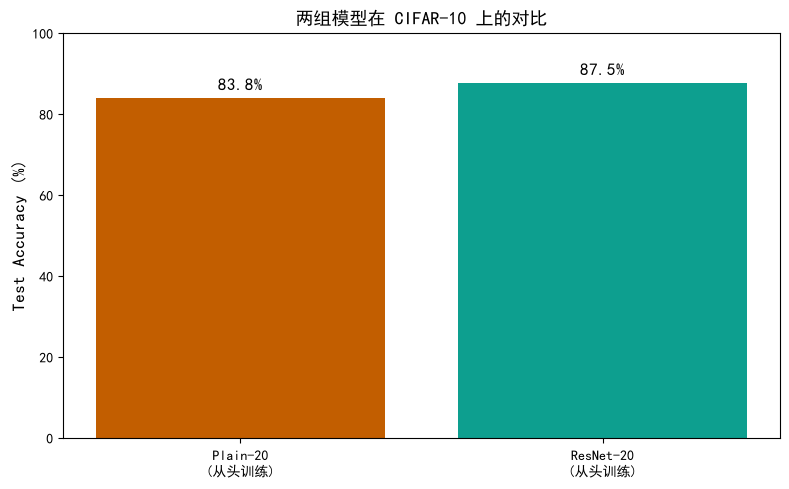

In [11]:
results = {
    'Plain-20\n(从头训练)': history_plain['test_acc'][-1],
    'ResNet-20\n(从头训练)': history_resnet20['test_acc'][-1]
}

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#c25e00', '#0d9f8f']
bars = ax.bar(results.keys(), results.values(), color=colors)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('两组模型在 CIFAR-10 上的对比', fontsize=13, fontweight='bold')
ax.set_ylim(0, 100)
for bar, v in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, v + 2, f"{v:.1f}%",
            ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 13. 核心结论

| 对比 | 说明 | 预期结果 |
|------|------|----------|
| Plain-20 vs ResNet-20 | 同结构（20 层），唯一区别是残差连接 | ResNet-20 更好，体现残差连接解决退化问题的价值 |

残差连接的作用：
1. 让深层网络可以训练，缓解退化问题
2. 提供梯度高速公路，缓解梯度消失
3. 让网络可以选择学习残差而不是直接学习恒等映射


## 14. 动手练习

### 练习 1：增加网络深度
把 ResNet-20 改成 ResNet-32（每个 stage 5 个 block），看看准确率是否继续提升。

### 练习 2：去掉 BatchNorm
在 PlainBlock 和 BasicBlock 中去掉 BatchNorm，重新训练。观察 BN 对训练稳定性的影响。

### 练习 3：只看 shortcut
实现一个只有 shortcut、中间卷积为空的 BasicBlock，验证网络是否能学到恒等映射。

### 练习 4：迁移学习初探
本节课没有涉及迁移学习。后续课程会专门讲如何用预训练模型解决实际任务。


## 15. 常见问题

**Q1：为什么 Plain-20 会退化？**
A：因为深层网络中梯度传递困难，参数难以有效更新。即使网络有表达能力，也训练不出来。

**Q2：ResNet-20 和 ResNet-18 有什么区别？**
A：ResNet-20 是原论文中为 CIFAR-10 设计的结构，第一层是 3×3；ResNet-18 是为 ImageNet 设计的，第一层是 7×7。

**Q3：shortcut 中的 1×1 卷积什么时候用？**
A：当输入和输出通道数不同，或者 stride 不为 1 时，需要用 1×1 卷积调整维度后才能相加。

**Q4：迁移学习什么时候讲？**
A：本节课聚焦残差连接。迁移学习会在目标检测、分割等实际应用课程中深入讲解。


## 16. 小结

- 深层网络存在**退化问题**，不是过拟合，而是训练困难
- **残差连接** $y = F(x) + x$ 解决了这个问题
- 控制变量实验显示：同结构的 Plain-20 和 ResNet-20，后者因为残差连接训练得更好
- ResNet 缓解梯度消失，让深层参数得到有效更新
- 迁移学习是另一个重要主题，但本节课不展开，后续课程会结合实际应用讲解

下一节课，我们将学习训练技巧：优化器、BatchNorm、Dropout、学习率调度。
